# 🎮 Experiment 5: Naïve Bayes Classification on Video Game Sales

**Date:** 11/02/2026

## 🎯 Aim
To apply Naïve Bayes classification on video game sales data.

## 📘 Theory
Naïve Bayes is a probabilistic classification algorithm based on Bayes’ theorem.

It assumes features are independent and works well on large datasets.

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Load Dataset

In [2]:
# Ensure vgsales.csv is in the same directory

df = pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 🧹 Handling Missing Values

In [3]:
df = df.dropna()

## 🎯 Creating Sales Categories
Video games are divided into Low, Medium, and High based on Global Sales quantiles.

In [4]:
q1 = df['Global_Sales'].quantile(0.33)
q2 = df['Global_Sales'].quantile(0.66)

def sales_cat(x):
    if x <= q1:
        return 0  # Low
    elif x <= q2:
        return 1  # Medium
    else:
        return 2  # High

df['Sales_Class'] = df['Global_Sales'].apply(sales_cat)

df[['Global_Sales','Sales_Class']].head()

,Global_Sales,Sales_Class
0,82.74,2
1,40.24,2
2,35.82,2
3,33.00,2
4,31.37,2


## 🔍 Feature Selection

In [5]:
X = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]
y = df['Sales_Class']

X.shape, y.shape

((16291, 4), (16291,))

## ✂️ Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 🧠 Training Naïve Bayes Model

In [7]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 🔮 Prediction

In [8]:
y_pred = nb.predict(X_test)
y_pred_proba = nb.predict_proba(X_test)

y_pred[:10]

array([2, 0, 1, 2, 1, 1, 1, 1, 0, 1])

## 📊 Model Evaluation

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8866612111292962
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1691
           1       0.76      0.94      0.84      1554
           2       0.99      0.78      0.87      1643

    accuracy                           0.89      4888
   macro avg       0.90      0.89      0.89      4888
weighted avg       0.90      0.89      0.89      4888



## 🔲 Confusion Matrix

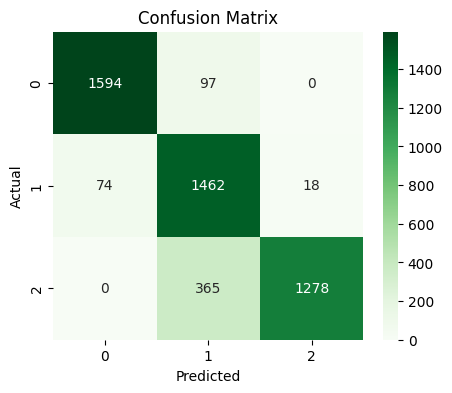

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 📈 ROC Curve (Multi-class)

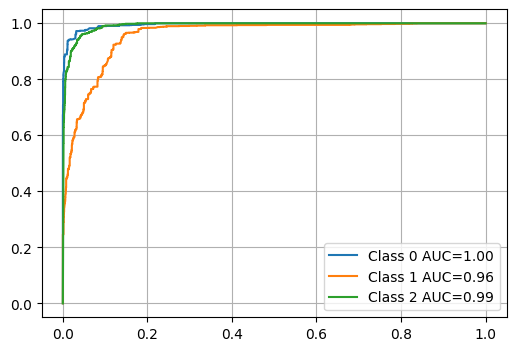

In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr, tpr, roc_auc = {}, {}, {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,4))

for i, color in zip(range(3), ['blue','red','green']):
    plt.plot(fpr[i], tpr[i],
             label=f"Class {i} AUC={roc_auc[i]:.2f}")

plt.legend()
plt.grid(True)
plt.show()

## 📊 Prediction Probability Distribution

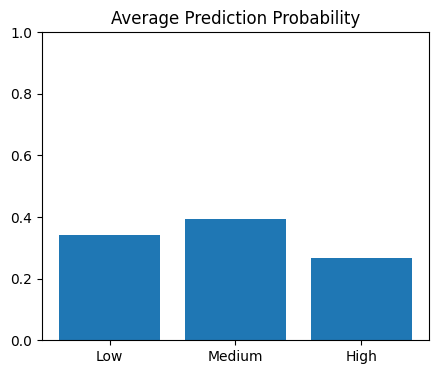

In [12]:
mean_probs = np.mean(y_pred_proba, axis=0)

plt.figure(figsize=(5,4))
plt.bar(['Low','Medium','High'], mean_probs)
plt.ylim([0,1])
plt.title("Average Prediction Probability")
plt.show()